In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RAW_PATH = "/home/sebas/data/capuccinoIndex/Cappuccino Index 2026 (public).xlsx"

full_data = pd.read_excel(RAW_PATH, sheet_name="full_data").dropna(axis=1, how="all")
capp_index_all_countries = pd.read_excel(RAW_PATH, sheet_name="capp_index_all_countries").dropna(axis=1, how="all")
index_n10 = pd.read_excel(RAW_PATH, sheet_name="index_(n≥10)").dropna(axis=1, how="all")

full_data["local_index_min"] = full_data["Price per small cappuccino"] / full_data["Hourly wage"] * 60

In [2]:
# Shared chart styling: thin recessive gridlines/spines, single sequential hue (blue) for single-series charts
BLUE = "#2a78d6"
ORANGE = "#eb6834"
AQUA = "#1baf7a"
GRIDLINE = "#e1e0d9"
AXIS = "#c3c2b7"
MUTED = "#898781"
PRIMARY_INK = "#0b0b0b"


def style_ax(ax):
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color(AXIS)
    ax.tick_params(colors=MUTED, labelsize=9)
    ax.title.set_color(PRIMARY_INK)

## Cappuccino index by country (n \u2265 10 entries)

Minutes of work needed to afford a small cappuccino, ranked low to high.

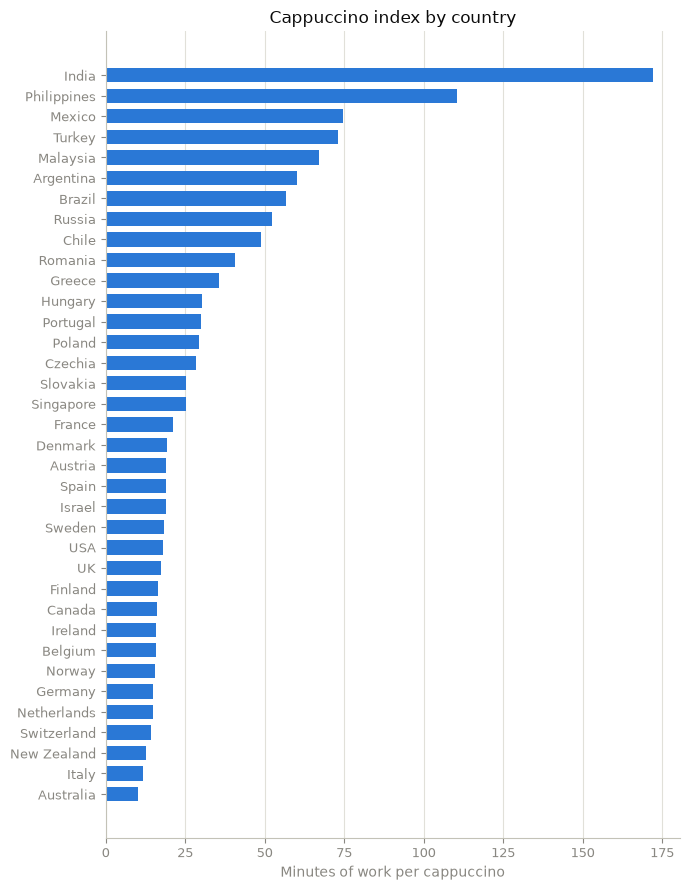

In [3]:
ranked = index_n10.sort_values("Index Number", ascending=True)

fig, ax = plt.subplots(figsize=(7, 9))
ax.barh(ranked["Country"], ranked["Index Number"], color=BLUE, height=0.7)
ax.set_xlabel("Minutes of work per cappuccino", color=MUTED)
ax.set_title("Cappuccino index by country")
ax.xaxis.grid(True, color=GRIDLINE, linewidth=0.8)
ax.set_axisbelow(True)
style_ax(ax)
fig.tight_layout()

## Distribution of the index across individual entries

Every row in `full_data`, not just country averages — shows the spread and skew that the per-country index hides.

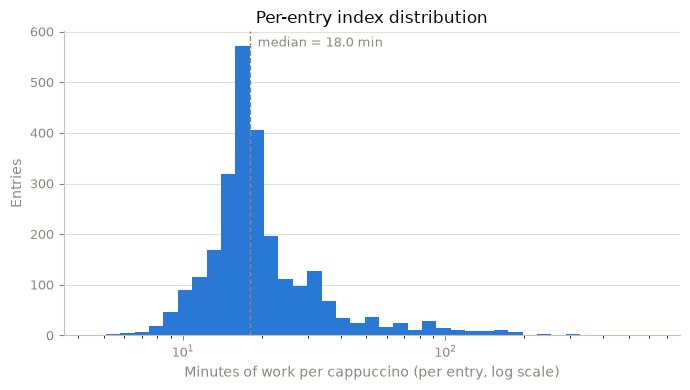

In [4]:
median_min = full_data["local_index_min"].median()
bins = np.logspace(np.log10(full_data["local_index_min"].min()), np.log10(full_data["local_index_min"].max()), 40)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(full_data["local_index_min"], bins=bins, color=BLUE)
ax.axvline(median_min, color=MUTED, linestyle="--", linewidth=1)
ax.text(median_min, ax.get_ylim()[1] * 0.95, f"  median = {median_min:.1f} min", color=MUTED, fontsize=9)
ax.set_xscale("log")
ax.set_xlabel("Minutes of work per cappuccino (per entry, log scale)", color=MUTED)
ax.set_ylabel("Entries", color=MUTED)
ax.set_title("Per-entry index distribution")
ax.yaxis.grid(True, color=GRIDLINE, linewidth=0.8)
ax.set_axisbelow(True)
style_ax(ax)
fig.tight_layout()

## Sample size per country — data quality

Most countries have very few entries; the dashed line marks the n \u2265 10 cutoff used for `index_(n\u226510)`.

51 of 87 countries have fewer than 10 entries


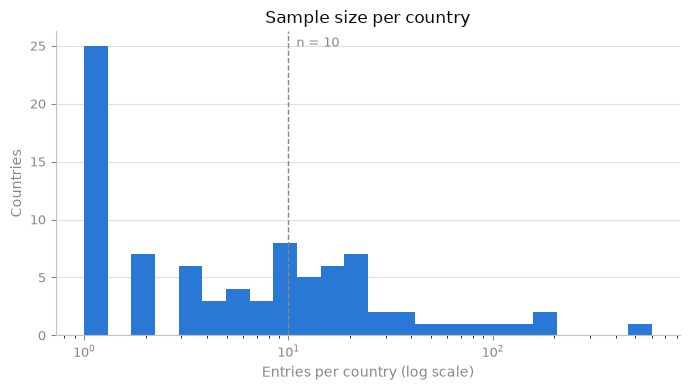

In [5]:
bins = np.logspace(0, np.log10(capp_index_all_countries["Data Entries"].max()), 25)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(capp_index_all_countries["Data Entries"], bins=bins, color=BLUE)
ax.axvline(10, color=MUTED, linestyle="--", linewidth=1)
ax.text(10, ax.get_ylim()[1] * 0.95, "  n = 10", color=MUTED, fontsize=9)
ax.set_xscale("log")
ax.set_xlabel("Entries per country (log scale)", color=MUTED)
ax.set_ylabel("Countries", color=MUTED)
ax.set_title("Sample size per country")
ax.yaxis.grid(True, color=GRIDLINE, linewidth=0.8)
ax.set_axisbelow(True)
style_ax(ax)
fig.tight_layout()

print(f"{(capp_index_all_countries['Data Entries'] < 10).sum()} of {len(capp_index_all_countries)} countries have fewer than 10 entries")

## Data quality notes

Two things worth keeping in mind before drawing conclusions from `full_data`:

In [6]:
missing_city = full_data["City"].isna().sum()
multi_label_urban = full_data["Urban classification"].str.contains(",", na=False).sum()

print(f"{missing_city} of {len(full_data)} entries are missing City")
print(f"{multi_label_urban} of {len(full_data)} entries have a multi-label Urban classification (e.g. 'Urban, Suburban')")

169 of 2594 entries are missing City
63 of 2594 entries have a multi-label Urban classification (e.g. 'Urban, Suburban')


## Countries by number of entries

All 87 countries, ranked. Same underlying counts as the histogram above, but per-country.

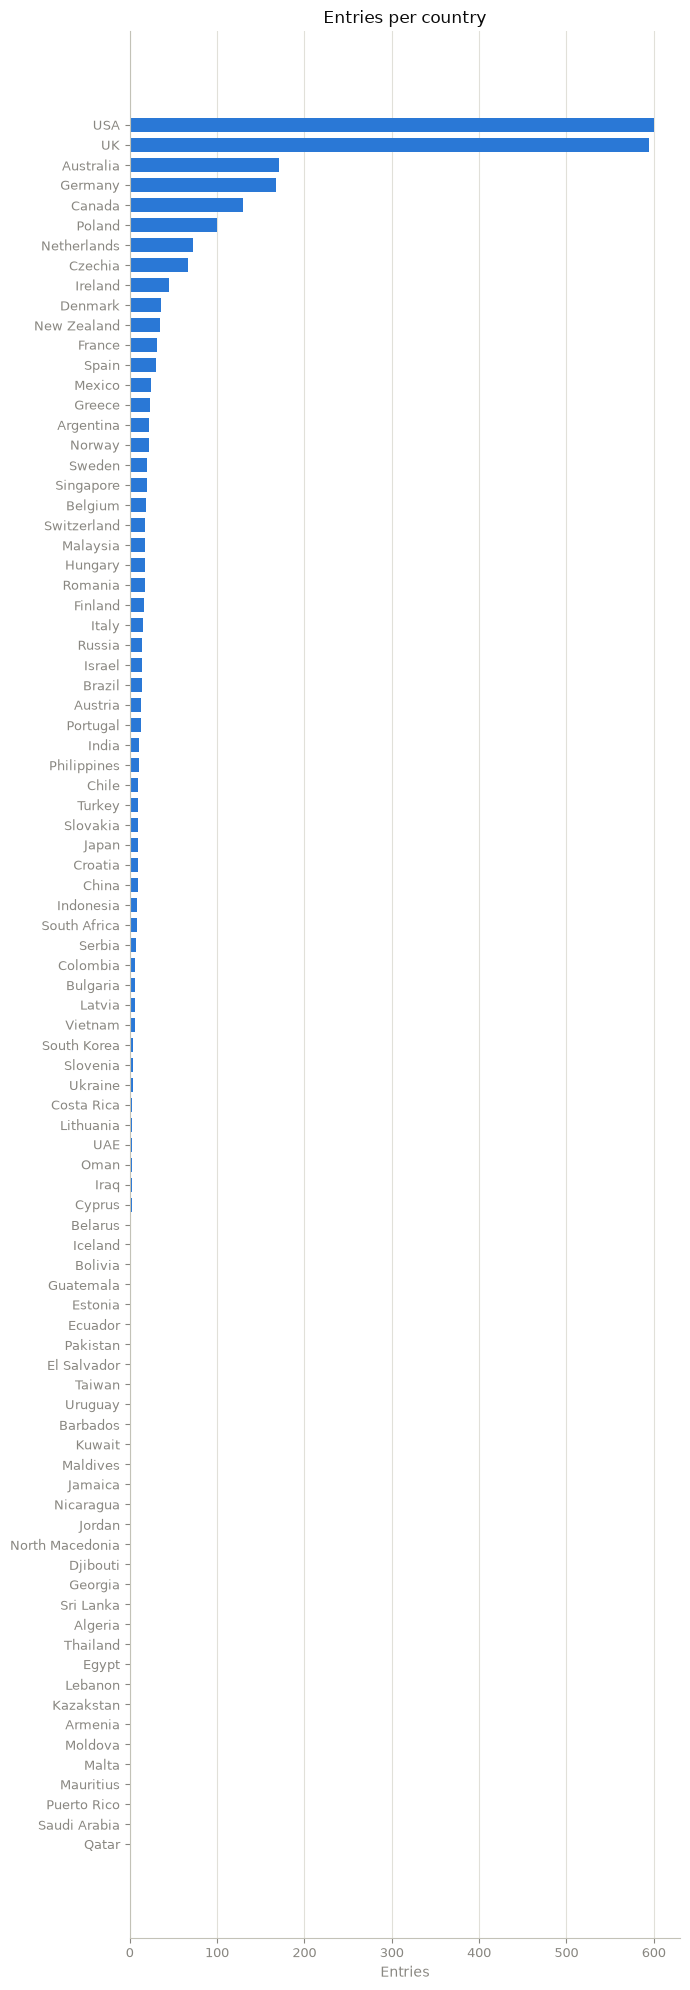

In [7]:
entries_by_country = full_data["Country"].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 20))
ax.barh(entries_by_country.index, entries_by_country.values, color=BLUE, height=0.7)
ax.set_xlabel("Entries", color=MUTED)
ax.set_title("Entries per country")
ax.xaxis.grid(True, color=GRIDLINE, linewidth=0.8)
ax.set_axisbelow(True)
style_ax(ax)
fig.tight_layout()

## Urban / suburban / rural breakdown — top 3 countries by entries

Restricted to single-label rows (drops the 63 multi-label entries noted above, e.g. "Urban, Suburban") so each entry counts toward exactly one class.

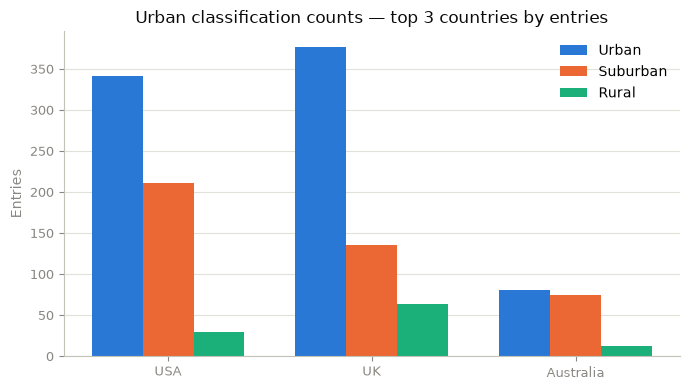

In [8]:
top3_countries = full_data["Country"].value_counts().head(3).index.tolist()
single_label = full_data[full_data["Country"].isin(top3_countries) & ~full_data["Urban classification"].str.contains(",", na=False)]

classes = ["Urban", "Suburban", "Rural"]
counts = single_label.groupby(["Country", "Urban classification"]).size().unstack(fill_value=0).reindex(top3_countries)[classes]

x = np.arange(len(top3_countries))
width = 0.25
colors = [BLUE, ORANGE, AQUA]

fig, ax = plt.subplots(figsize=(7, 4))
for i, cls in enumerate(classes):
    ax.bar(x + (i - 1) * width, counts[cls], width=width, label=cls, color=colors[i])
ax.set_xticks(x)
ax.set_xticklabels(top3_countries)
ax.set_ylabel("Entries", color=MUTED)
ax.set_title("Urban classification counts — top 3 countries by entries")
ax.yaxis.grid(True, color=GRIDLINE, linewidth=0.8)
ax.set_axisbelow(True)
ax.legend(frameon=False)
style_ax(ax)
fig.tight_layout()

## Mean price, wage, and index per country

In [9]:
country_means = full_data.groupby("Country").agg(
    price_gbp=("Price per cappuccino in GBP", "mean"),
    wage_gbp=("Hourly wage in GBP", "mean"),
    index_min=("local_index_min", "mean"),
    n=("Country", "size"),
).round(2)

country_means.sort_values("n", ascending=False)

,price_gbp,wage_gbp,index_min,n
Country,,,,
USA,3.67,12.29,19.07,600
UK,3.84,13.16,17.65,595
Australia,2.75,16.40,10.28,171
Germany,3.35,13.44,15.49,167
Canada,2.77,10.27,16.64,130
...,...,...,...,...
North Macedonia,1.67,3.28,30.64,1
Taiwan,4.60,5.06,54.55,1
Sri Lanka,1.33,0.58,138.46,1


## Cappuccino price vs. hourly wage (GBP) — across countries

One point per country, using the per-country means above.

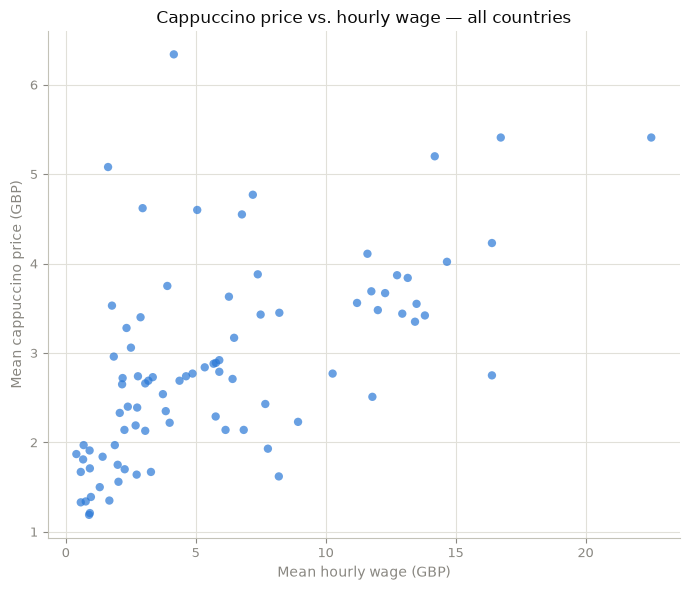

In [10]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(country_means["wage_gbp"], country_means["price_gbp"], color=BLUE, alpha=0.7, edgecolor="none")
ax.set_xlabel("Mean hourly wage (GBP)", color=MUTED)
ax.set_ylabel("Mean cappuccino price (GBP)", color=MUTED)
ax.set_title("Cappuccino price vs. hourly wage — all countries")
ax.grid(True, color=GRIDLINE, linewidth=0.8)
ax.set_axisbelow(True)
style_ax(ax)
fig.tight_layout()

In [11]:
from scipy import stats

r, p_corr = stats.pearsonr(country_means["wage_gbp"], country_means["price_gbp"])
fit = stats.linregress(country_means["wage_gbp"], country_means["price_gbp"])

print(f"Pearson r = {r:.3f} (p = {p_corr:.3g}, n = {len(country_means)})")
print(f"Linear fit: price = {fit.slope:.3f} * wage + {fit.intercept:.3f}")
print(f"R^2 = {fit.rvalue ** 2:.3f}, slope stderr = {fit.stderr:.3f}, slope p = {fit.pvalue:.3g}")

Pearson r = 0.588 (p = 2.1e-09, n = 87)
Linear fit: price = 0.132 * wage + 2.085
R^2 = 0.346, slope stderr = 0.020, slope p = 2.1e-09


## Same comparison, restricted to countries with more than 8 entries

39 of 87 countries qualify.

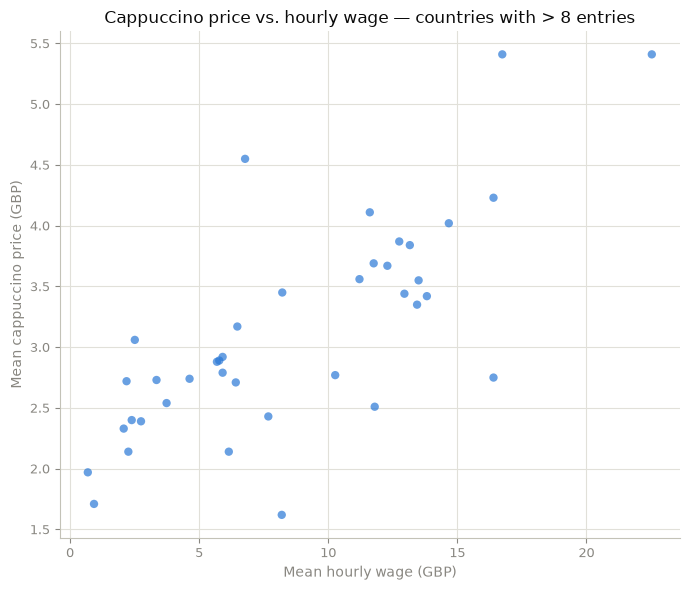

In [12]:
filtered_means = country_means[country_means["n"] > 8]

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(filtered_means["wage_gbp"], filtered_means["price_gbp"], color=BLUE, alpha=0.7, edgecolor="none")
ax.set_xlabel("Mean hourly wage (GBP)", color=MUTED)
ax.set_ylabel("Mean cappuccino price (GBP)", color=MUTED)
ax.set_title("Cappuccino price vs. hourly wage — countries with > 8 entries")
ax.grid(True, color=GRIDLINE, linewidth=0.8)
ax.set_axisbelow(True)
style_ax(ax)
fig.tight_layout()

In [13]:
r_f, p_corr_f = stats.pearsonr(filtered_means["wage_gbp"], filtered_means["price_gbp"])
fit_f = stats.linregress(filtered_means["wage_gbp"], filtered_means["price_gbp"])

print(f"Pearson r = {r_f:.3f} (p = {p_corr_f:.3g}, n = {len(filtered_means)})")
print(f"Linear fit: price = {fit_f.slope:.3f} * wage + {fit_f.intercept:.3f}")
print(f"R^2 = {fit_f.rvalue ** 2:.3f}, slope stderr = {fit_f.stderr:.3f}, slope p = {fit_f.pvalue:.3g}")

Pearson r = 0.750 (p = 3.9e-08, n = 39)
Linear fit: price = 0.124 * wage + 2.055
R^2 = 0.562, slope stderr = 0.018, slope p = 3.9e-08


## Price and wage by urban classification — top 3 countries

Same top-3-by-entries countries as the urban breakdown above. Multi-label rows
(e.g. "Urban, Suburban") are counted in every class they list, so entry counts
per box exceed the single-label-only counts shown earlier.

In [14]:
import matplotlib.patches as mpatches

exploded = full_data[["Country", "Urban classification", "Price per cappuccino in GBP", "Hourly wage in GBP"]].copy()
exploded["Urban classification"] = exploded["Urban classification"].str.split(",")
exploded = exploded.explode("Urban classification")
exploded["Urban classification"] = exploded["Urban classification"].str.strip()
exploded = exploded[exploded["Country"].isin(top3_countries) & exploded["Urban classification"].isin(classes)]


def grouped_boxplot(ax, value_col, ylabel, title):
    x = np.arange(len(top3_countries))
    width = 0.25
    for i, cls in enumerate(classes):
        data = [
            exploded[(exploded["Country"] == c) & (exploded["Urban classification"] == cls)][value_col].dropna()
            for c in top3_countries
        ]
        positions = x + (i - 1) * width
        bp = ax.boxplot(
            data,
            positions=positions,
            widths=width * 0.85,
            patch_artist=True,
            medianprops={"color": PRIMARY_INK},
            boxprops={"facecolor": colors[i], "edgecolor": AXIS},
            whiskerprops={"color": AXIS},
            capprops={"color": AXIS},
            flierprops={"markeredgecolor": AXIS, "markersize": 4},
        )
    ax.set_xticks(x)
    ax.set_xticklabels(top3_countries)
    ax.set_ylabel(ylabel, color=MUTED)
    ax.set_title(title)
    ax.yaxis.grid(True, color=GRIDLINE, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.legend(
        [mpatches.Patch(facecolor=c) for c in colors],
        classes,
        frameon=False,
    )
    style_ax(ax)

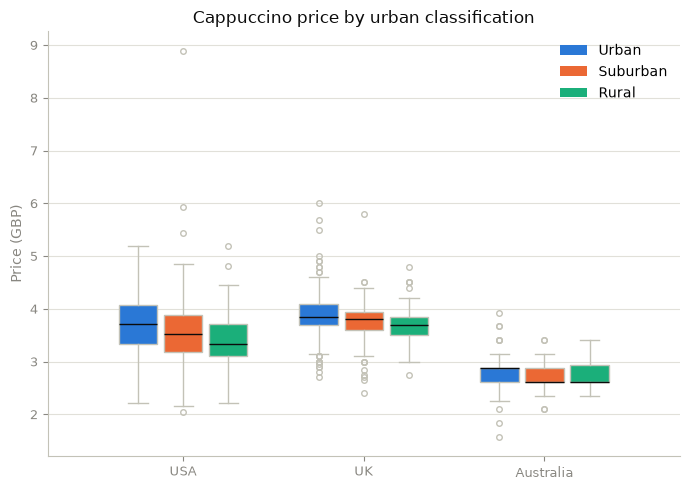

In [15]:
fig, ax = plt.subplots(figsize=(7, 5))
grouped_boxplot(ax, "Price per cappuccino in GBP", "Price (GBP)", "Cappuccino price by urban classification")
fig.tight_layout()

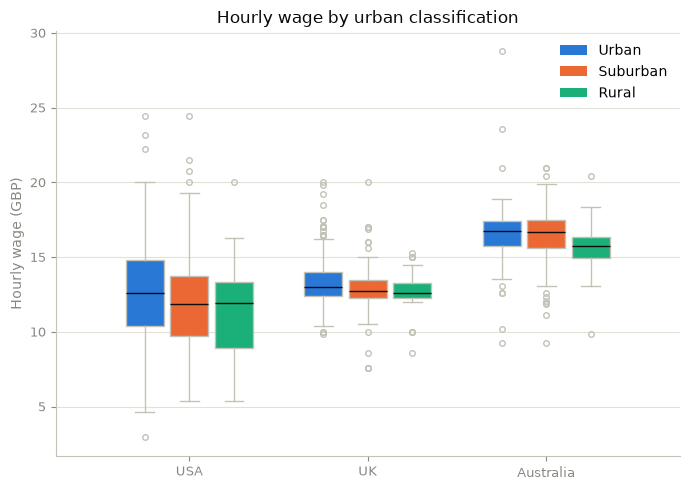

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))
grouped_boxplot(ax, "Hourly wage in GBP", "Hourly wage (GBP)", "Hourly wage by urban classification")
fig.tight_layout()